In [1]:
import os
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
from torchvision import models, transforms

In [2]:
DATASET_PATH = r"C:\Users\Admin\OneDrive\Desktop\Visual_Defect_Detection\archive\NEU-DET"

MODEL_PATH = r"C:\Users\Admin\OneDrive\Desktop\Visual_Defect_Detection\models\best_resnet18_neu_det.pth"

classes = [
    "crazing",
    "inclusion",
    "patches",
    "pitted_surface",
    "rolled-in_scale",
    "scratches"
]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)
print("Classes:", classes)

Device: cpu
Classes: ['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches']


In [3]:
model = models.resnet18(weights=None)

num_features = model.fc.in_features

model.fc = nn.Linear(num_features, len(classes))

model = model.to(device)

print("ResNet18 model created successfully!")

ResNet18 model created successfully!


In [4]:
model.load_state_dict(
    torch.load(
        MODEL_PATH,
        map_location=device,
        weights_only=True
    )
)

model.eval()

print("Trained ResNet18 model loaded successfully!")

Trained ResNet18 model loaded successfully!


In [5]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("Image transformation ready!")

Image transformation ready!


In [7]:
image_path = os.path.join(
    DATASET_PATH,
    "validation",
    "images",
    "scratches",
    "scratches_241.jpg"
)

print("Image path:", image_path)
print("Image exists:", os.path.exists(image_path))

Image path: C:\Users\Admin\OneDrive\Desktop\Visual_Defect_Detection\archive\NEU-DET\validation\images\scratches\scratches_241.jpg
Image exists: True


In [8]:
original_image = Image.open(image_path).convert("RGB")

input_tensor = transform(original_image).unsqueeze(0)

input_tensor = input_tensor.to(device)

print("Image loaded successfully!")
print("Input shape:", input_tensor.shape)

Image loaded successfully!
Input shape: torch.Size([1, 3, 224, 224])


In [9]:
with torch.no_grad():
    outputs = model(input_tensor)

probabilities = torch.softmax(outputs, dim=1)

predicted_class = torch.argmax(probabilities, dim=1).item()

confidence = probabilities[0][predicted_class].item()

print("Predicted class:", classes[predicted_class])
print(f"Confidence: {confidence * 100:.2f}%")

Predicted class: scratches
Confidence: 99.99%


In [10]:
class GradCAM:
    
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        
        self.activations = None
        self.gradients = None
        
        target_layer.register_forward_hook(self.save_activation)
        target_layer.register_full_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def generate(self, input_tensor, class_index):
        
        self.model.zero_grad()
        
        output = self.model(input_tensor)
        
        score = output[0, class_index]
        
        score.backward()
        
        gradients = self.gradients
        activations = self.activations
        
        weights = gradients.mean(dim=(2, 3), keepdim=True)
        
        cam = (weights * activations).sum(dim=1)
        
        cam = torch.relu(cam)
        
        cam = cam.squeeze().detach().cpu().numpy()
        
        cam = cam - cam.min()
        
        if cam.max() != 0:
            cam = cam / cam.max()
        
        return cam

In [11]:
target_layer = model.layer4[-1]

grad_cam = GradCAM(model, target_layer)

print("Grad-CAM initialized successfully!")

Grad-CAM initialized successfully!


In [12]:
cam = grad_cam.generate(
    input_tensor,
    predicted_class
)

print("Grad-CAM heatmap generated!")
print("Heatmap shape:", cam.shape)

Grad-CAM heatmap generated!
Heatmap shape: (7, 7)


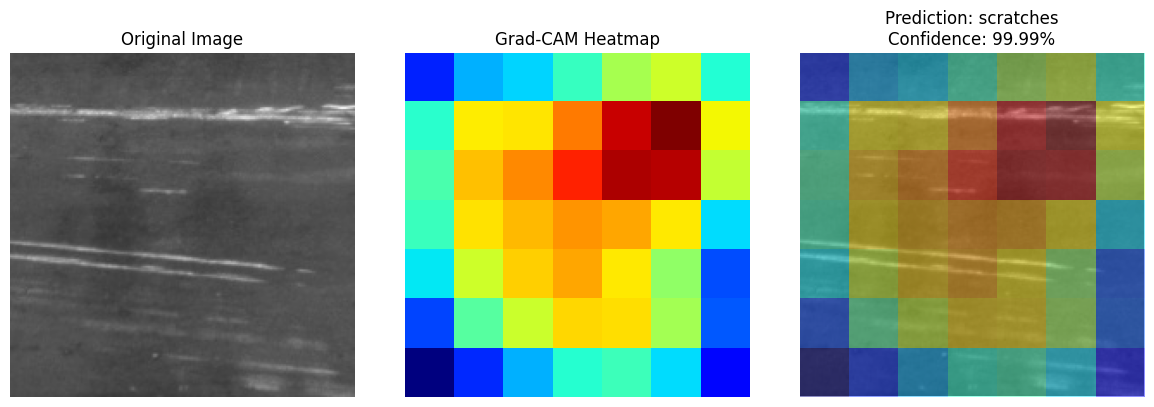

In [13]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(original_image)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(cam, cmap="jet")
plt.title("Grad-CAM Heatmap")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(original_image)
plt.imshow(
    cam,
    cmap="jet",
    alpha=0.45,
    extent=(
        0,
        original_image.size[0],
        original_image.size[1],
        0
    )
)
plt.title(
    f"Prediction: {classes[predicted_class]}\n"
    f"Confidence: {confidence * 100:.2f}%"
)
plt.axis("off")

plt.tight_layout()
plt.show()